In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ajeetkumar20/unsw-nb15-v1-1")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/ajeetkumar20/unsw-nb15-v1-1


In [4]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Download latest version
path = kagglehub.dataset_download("ajeetkumar20/unsw-nb15-v1-1")
print("Path to dataset files:", path)

# Find the CSV files in the downloaded directory
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("Available CSV files:", csv_files)

# Assuming standard UNSW-NB15 split files are named 'UNSW_NB15_training-set.csv' and 'UNSW_NB15_testing-set.csv'
# Adjust the filenames below if they differ in the downloaded directory
train_path = os.path.join(path, 'UNSW_NB15_training-set.csv')
test_path = os.path.join(path, 'UNSW_NB15_testing-set.csv')

# Load the datasets
df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# Combine for comprehensive EDA
df = pd.concat([df_train, df_test], ignore_index=True)
print(f"Total dataset shape: {df.shape}")

Path to dataset files: /kaggle/input/datasets/ajeetkumar20/unsw-nb15-v1-1
Available CSV files: ['UNSW_NB15_testing-set.csv', 'UNSW_NB15_training-set.csv']
Total dataset shape: (257673, 45)


In [5]:
# Display the first few rows
display(df.head())

# Check data types and non-null counts
print("\n--- Dataset Info ---")
df.info()

# Check for missing values
print("\n--- Missing Values ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# Summary statistics for numerical columns
display(df.describe())

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257673 entries, 0 to 257672
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 257673 non-null  int64  
 1   dur                257673 non-null  float64
 2   proto              257673 non-null  object 
 3   service            257673 non-null  object 
 4   state              257673 non-null  object 
 5   spkts              257673 non-null  int64  
 6   dpkts              257673 non-null  int64  
 7   sbytes             257673 non-null  int64  
 8   dbytes             257673 non-null  int64  
 9   rate               257673 non-null  float64
 10  sttl               257673 non-null  int64  
 11  dttl               257673 non-null  int64  
 12  sload              257673 non-null  float64
 13  dload              257673 non-null  float64
 14  sloss              257673 non-null  int64  
 15  dloss              257673 non

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,257673.000000,257673.000000,257673.000000,257673.000000,2.576730e+05,2.576730e+05,2.576730e+05,257673.000000,257673.000000,2.576730e+05,...,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000,257673.000000
mean,72811.823858,1.246715,19.777144,18.514703,8.572952e+03,1.438729e+04,9.125391e+04,180.000931,84.754957,7.060869e+07,...,5.238271,4.032677,8.322964,0.012819,0.012850,0.132005,6.800045,9.121049,0.014274,0.639077
std,48929.917641,5.974305,135.947152,111.985965,1.737739e+05,1.461993e+05,1.603446e+05,102.488268,112.762131,1.857313e+08,...,8.160822,5.831515,11.120754,0.116091,0.116421,0.681854,8.396266,10.874752,0.118618,0.480269
min,1.000000,0.000000,1.000000,0.000000,2.400000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,32210.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.078928e+01,62.000000,0.000000,1.231800e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,64419.000000,0.004285,4.000000,2.000000,5.280000e+02,1.780000e+02,2.955665e+03,254.000000,29.000000,7.439423e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,110923.000000,0.685777,12.000000,10.000000,1.362000e+03,1.064000e+03,1.250000e+05,254.000000,252.000000,8.000000e+07,...,4.000000,3.000000,8.000000,0.000000,0.000000,0.000000,8.000000,11.000000,0.000000,1.000000
max,175341.000000,59.999989,10646.000000,11018.000000,1.435577e+07,1.465753e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,59.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


/tmp/ipykernel_57/1051074917.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.countplot(x='label', data=df, palette='Set2')
/tmp/ipykernel_57/1051074917.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.countplot(y='attack_cat', data=attacks_only, order=attacks_only['attack_cat'].value_counts().index, palette='husl')


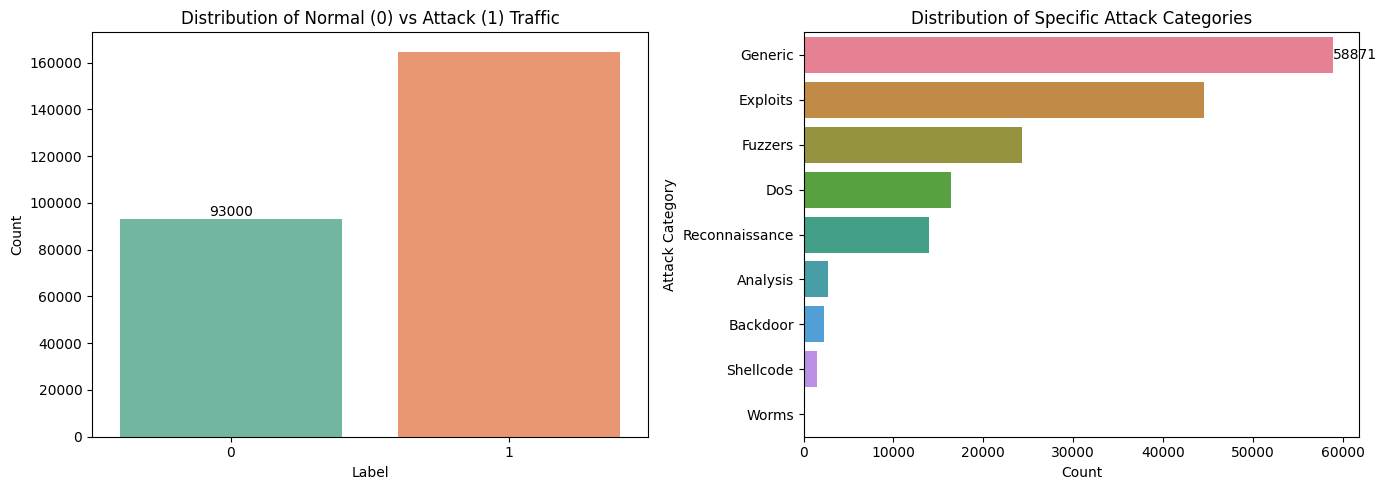

In [6]:
plt.figure(figsize=(14, 5))

# Binary Target (label)
plt.subplot(1, 2, 1)
ax1 = sns.countplot(x='label', data=df, palette='Set2')
plt.title('Distribution of Normal (0) vs Attack (1) Traffic')
plt.xlabel('Label')
plt.ylabel('Count')
ax1.bar_label(ax1.containers[0])

# Multi-class Target (attack_cat)
plt.subplot(1, 2, 2)
# Filter out 'Normal' to just see the distribution of different attack types
attacks_only = df[df['label'] == 1]
ax2 = sns.countplot(y='attack_cat', data=attacks_only, order=attacks_only['attack_cat'].value_counts().index, palette='husl')
plt.title('Distribution of Specific Attack Categories')
plt.xlabel('Count')
plt.ylabel('Attack Category')
ax2.bar_label(ax2.containers[0])

plt.tight_layout()
plt.show()


--- Categorical Columns ---
Index(['proto', 'service', 'state', 'attack_cat'], dtype='object')


/tmp/ipykernel_57/3395269149.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')
/tmp/ipykernel_57/3395269149.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')
/tmp/ipykernel_57/3395269149.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')


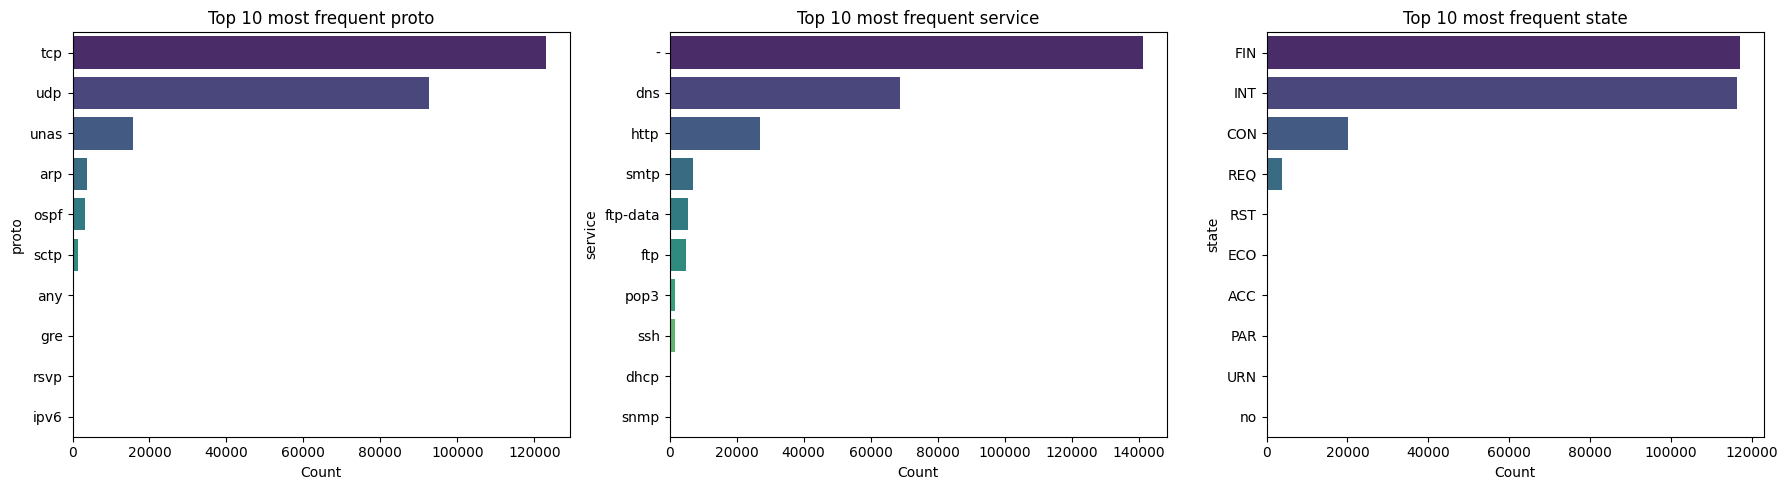

In [7]:
categorical_cols = df.select_dtypes(include=['object']).columns
print("\n--- Categorical Columns ---")
print(categorical_cols)

# Visualize the top 10 most frequent values for key categorical columns
features_to_plot = ['proto', 'service', 'state']

plt.figure(figsize=(18, 5))
for i, col in enumerate(features_to_plot, 1):
    plt.subplot(1, 3, i)
    top_10 = df[col].value_counts().head(10)
    sns.barplot(x=top_10.values, y=top_10.index, palette='viridis')
    plt.title(f'Top 10 most frequent {col}')
    plt.xlabel('Count')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

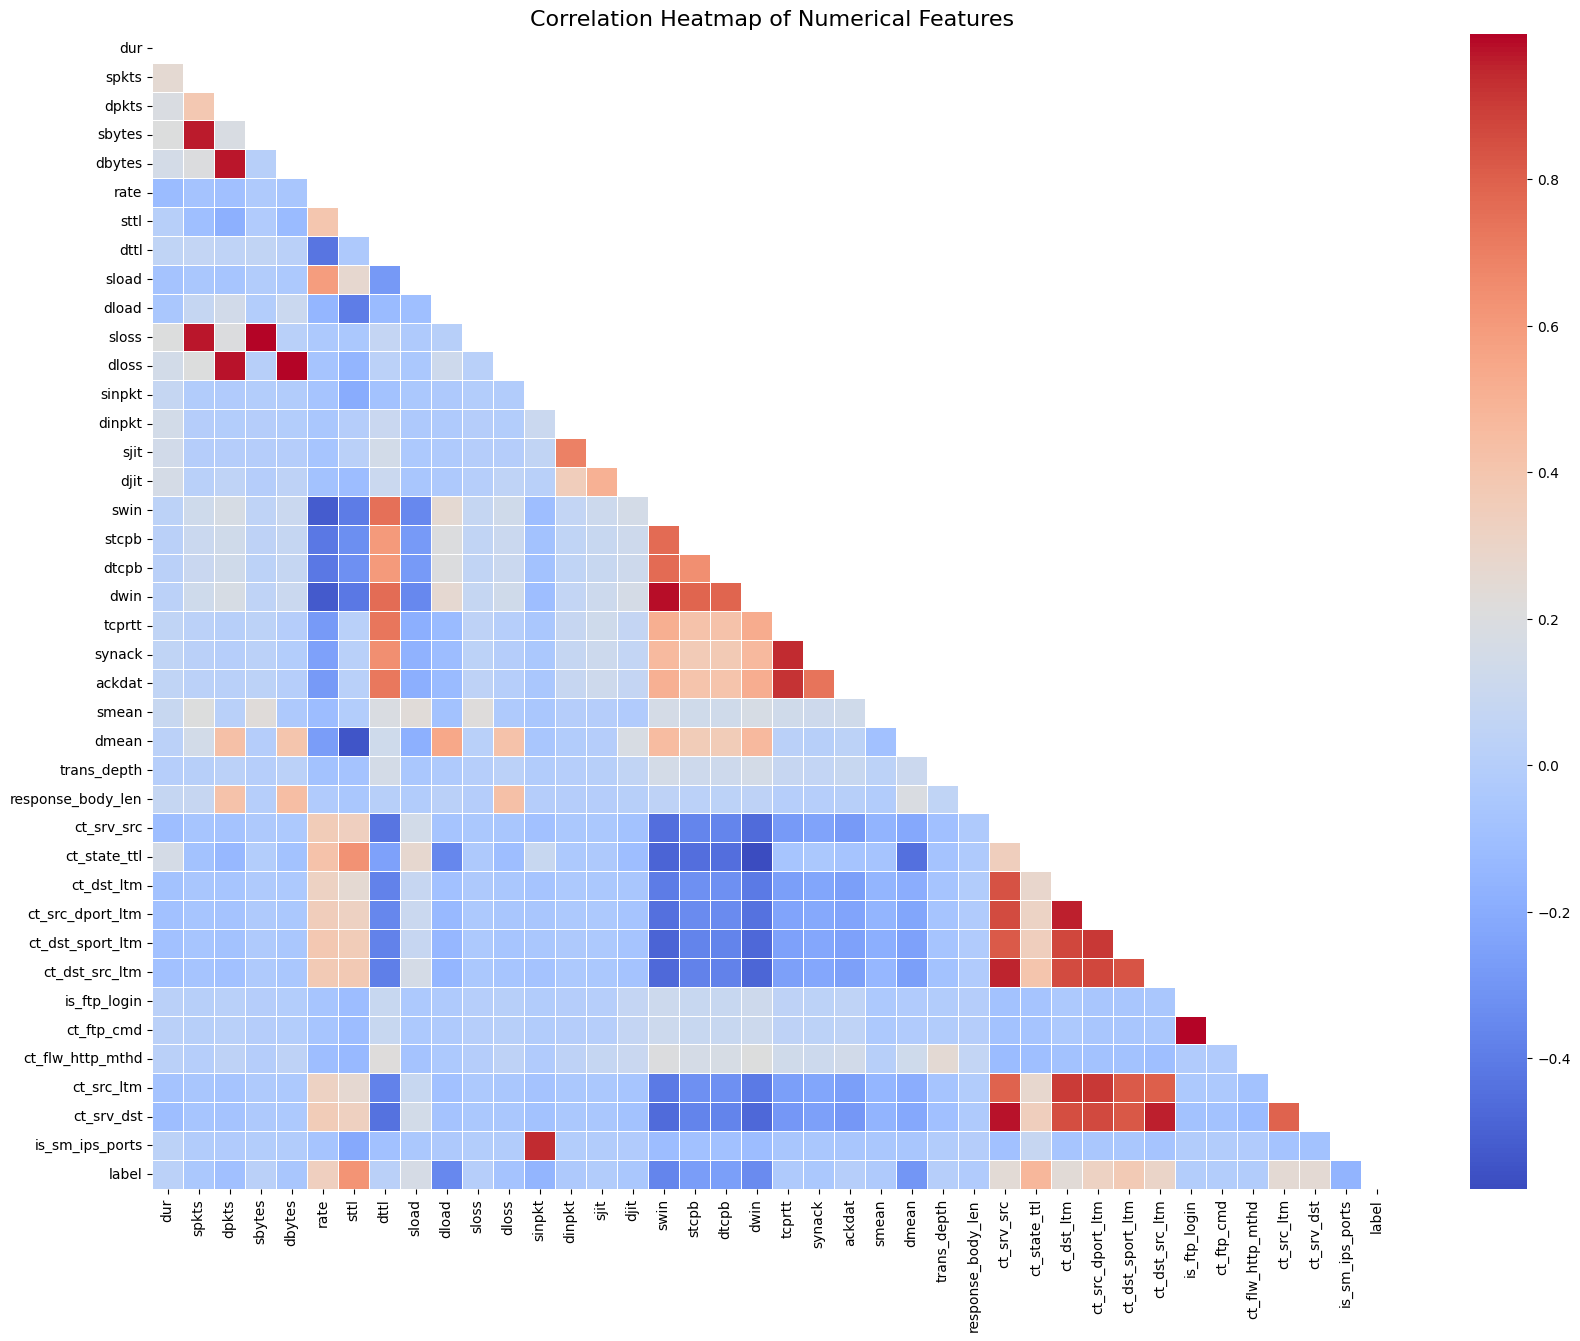


--- Highly Correlated Feature Pairs (|r| > 0.9) ---
spkts and sbytes: 0.964
spkts and sloss: 0.972
dpkts and dbytes: 0.973
dpkts and dloss: 0.980
sbytes and sloss: 0.996
dbytes and dloss: 0.997
sinpkt and is_sm_ips_ports: 0.942
swin and dwin: 0.980
tcprtt and synack: 0.943
tcprtt and ackdat: 0.920
ct_srv_src and ct_dst_src_ltm: 0.954
ct_srv_src and ct_srv_dst: 0.979
ct_dst_ltm and ct_src_dport_ltm: 0.962
ct_dst_ltm and ct_src_ltm: 0.902
ct_src_dport_ltm and ct_dst_sport_ltm: 0.908
ct_src_dport_ltm and ct_src_ltm: 0.909
ct_dst_src_ltm and ct_srv_dst: 0.960
is_ftp_login and ct_ftp_cmd: 0.999


In [8]:
# Select only numerical columns for correlation
numerical_df = df.select_dtypes(include=[np.number])

# Drop the 'id' column if it exists as it has no predictive power
if 'id' in numerical_df.columns:
    numerical_df = numerical_df.drop('id', axis=1)

# Calculate the correlation matrix
corr_matrix = numerical_df.corr()

# Plot the heatmap
plt.figure(figsize=(20, 15))
# Create a mask to hide the upper triangle for better readability
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.show()

# Identify highly correlated features (absolute correlation > 0.9)
high_corr_var = np.where(np.abs(corr_matrix) > 0.9)
high_corr_pairs = [(corr_matrix.columns[x], corr_matrix.columns[y]) for x, y in zip(*high_corr_var) if x != y and x < y]

print("\n--- Highly Correlated Feature Pairs (|r| > 0.9) ---")
for pair in high_corr_pairs:
    print(f"{pair[0]} and {pair[1]}: {corr_matrix.loc[pair[0], pair[1]]:.3f}")